<style>
    :root {
        --accent: #38bdf8;
        --bg-dark: #0f172a;
    }
    .jp-Notebook { background-color: var(--bg-dark) !important; color: #e2e8f0 !important; }
    .jp-RenderedHTMLCommon h1, .jp-RenderedHTMLCommon h2 { color: var(--accent) !important; border-bottom: 1px solid rgba(56, 189, 248, 0.2) !important; }
    .insight-card {
        background: rgba(56, 189, 248, 0.05);
        border-left: 4px solid var(--accent);
        padding: 1.2rem;
        border-radius: 8px;
        margin: 1rem 0;
    }
    .status-tag {
        background: var(--accent);
        color: var(--bg-dark);
        padding: 2px 8px;
        border-radius: 4px;
        font-weight: bold;
        font-size: 0.8em;
    }
</style>

# 🔬 Intel Core Ultra NPU: Unified GNN Benchmarking Suite

<span class="status-tag">ADVANCED ANALYTICS MODE</span>

This notebook provides a complete research pipeline with time-synchronized energy correlation for each model architecture.

In [1]:
import os, sys, json, shutil
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display, Markdown, HTML

RESULTS_DIR = Path("results")
MODELS_DIR = Path("models")
FIGURES_DIR = Path("paper/figures")

plt.style.use('dark_background')
sns.set_theme(style="darkgrid", palette="muted")
print("✅ Advanced Analytics Ready.")

✅ Advanced Analytics Ready.


### 📦 Step 1: Model Suite Generation
Ensuring models are standardized and quantized.

In [2]:
!python analysis/generate_gnn_models.py

  File "c:\Users\yusuf\Projects\npu-graph-opt-benchmarking\analysis\generate_gnn_models.py", line 117
    torch.onnx.export(
IndentationError: unexpected indent


### 📈 Step 2: Scalability & Timing Study
Executing models while recording high-precision start/end timestamps for energy correlation.

In [3]:
!python analysis/scalability_analyzer.py --iterations 100 --repeats 3

Processing model: APPNP_fp32.onnx
Processing model: APPNP_int8.onnx
Processing model: GAT_fp32.onnx
  -> Skipping model GAT_fp32.onnx due to error: [ONNXRuntimeError] : 1 : FAIL : Non-zero status code returned while running OpenVINO-EP-subgraph_15 node. Name:'OpenVINOExecutionProvider_OpenVINO-EP-subgraph_15_2' Status Message: C:\dev\packaging\ort-rel-1.24.1\onnxruntime\core\providers\openvino\backend_utils.cc:101 struct Ort::detail::ValueImpl<struct Ort::detail::Unowned<struct OrtValue> > __cdecl onnxruntime::openvino_ep::backend_utils::GetOutputTensor(struct Ort::KernelContext &,class std::basic_string<char,struct std::char_traits<char>,class std::allocator<char> >,const class std::unordered_map<class std::basic_string<char,struct std::char_traits<char>,class std::allocator<char> >,unsigned int,struct std::hash<class std::basic_string<char,struct std::char_traits<char>,class std::allocator<char> > >,struct std::equal_to<class std::basic_string<char,struct std::char_traits<char>,class

### 🔍 Step 3: Operator Profiling
Deep-dive into graph fusion and bottleneck identification.

In [4]:
!python analysis/profiling_analyzer.py


RESEARCH METRICS SUMMARY
----------------------------------------
Fusion Gain Ratio (FGR): 0.9940
Compilation Efficiency Index (CEI): 0.0000
NPU Support Ratio (Optimized): 33.1%
Baseline Latency: 160.79 ms
Optimized Latency: 161.76 ms
Latency Reduction: 0.00 ms

Detailed analysis saved to C:\Users\yusuf\Projects\npu-graph-opt-benchmarking\results


### 💻 Step 4: Hardware Comparison
Benchmarking all models across CPU, GPU, and NPU.

In [5]:
import glob
for model in sorted(glob.glob("models/*_fp32.onnx")):
    print(f"🚀 Device Comparison: {model}")
    !python analysis/hw_comparison.py --model {model} --iterations 100

🚀 Device Comparison: models\APPNP_fp32.onnx
[00:57:19] Starting 3-way hardware comparison for: APPNP_fp32.onnx
Configuration: 3 repeats of 100 iterations each.
[00:57:19] Testing device: CPU...
  -> Repeat 1/3...
  -> Repeat 2/3...
  -> Repeat 3/3...
[00:57:32] Device CPU completed (3 runs) in 12.57 seconds.
[00:57:32] Testing device: GPU...
  -> Repeat 1/3...
  -> Repeat 2/3...
  -> Repeat 3/3...
[00:57:47] Device GPU completed (3 runs) in 15.64 seconds.
[00:57:47] Testing device: NPU...
  -> Repeat 1/3...
  -> Repeat 2/3...
  -> Repeat 3/3...
[00:58:00] Device NPU completed (3 runs) in 12.25 seconds.
[00:58:00] Hardware comparison complete.
Total time: 40.76 seconds.
Results saved in: C:\Users\yusuf\Projects\npu-graph-opt-benchmarking\results\hw_comparison\APPNP_fp32
🚀 Device Comparison: models\GAT_fp32.onnx
[00:58:11] Starting 3-way hardware comparison for: GAT_fp32.onnx
Configuration: 3 repeats of 100 iterations each.
[00:58:11] Testing device: CPU...
  -> Repeat 1/3...
  ⚠️ Skip: 

 [ 0 ; 9 3 m 2 0 2 6 - 0 5 - 0 1   0 1 : 1 0 : 5 2 . 3 2 0 9 7 1 8   [ W : o n n x r u n t i m e : D e f a u l t ,   b a s i c _ b a c k e n d . c c : 1 2 3   o n n x r u n t i m e : : o p e n v i n o _ e p : : B a s i c B a c k e n d : : B a s i c B a c k e n d ]   M o d e l   c o m p i l a t i o n   f a i l e d   a t   O V   N P U . F a l l i n g   b a c k   t o   O V   C P U   f o r   e x e c u t i o n  [ m 
  [ 0 ; 9 3 m 2 0 2 6 - 0 5 - 0 1   0 1 : 1 1 : 0 4 . 2 8 1 8 0 5 1   [ W : o n n x r u n t i m e : D e f a u l t ,   b a s i c _ b a c k e n d . c c : 1 2 3   o n n x r u n t i m e : : o p e n v i n o _ e p : : B a s i c B a c k e n d : : B a s i c B a c k e n d ]   M o d e l   c o m p i l a t i o n   f a i l e d   a t   O V   N P U . F a l l i n g   b a c k   t o   O V   C P U   f o r   e x e c u t i o n  [ m 
  [ 0 ; 9 3 m 2 0 2 6 - 0 5 - 0 1   0 1 : 1 1 : 1 6 . 1 8 8 3 0 3 4   [ W : o n n x r u n t i m e : D e f a u l t ,   b a s i c _ b a c k e n d . c c : 1 2 3   o n 

### 🔋 Step 5: Energy Correlation Analysis
Correlating HWiNFO sensor logs with model timestamps to extract precise power metrics per architecture.

In [6]:
LOG_FILE = "results/hwinfo_log.csv"
MATRIX_FILE = "results/scalability_matrix.csv"

if Path(MATRIX_FILE).exists():
    print("🔗 Running Energy Analysis (using fallback estimation if logs missing)...")
    # We pass the log file path even if it doesn't exist, the script handles the fallback
    !python analysis/energy_analyzer.py --log {LOG_FILE} --matrix {MATRIX_FILE}
else:
    print("ℹ️ No scalability matrix found. Run Step 2 first.")

ℹ️ No log found in 'results/hwinfo_log.csv'. Run HWiNFO logging first.


### 📂 Step 6: Artifact Sync
Exporting all plots to paper directory.

In [7]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
for png in RESULTS_DIR.rglob("*.png"):
    shutil.copy2(png, FIGURES_DIR / png.name)
print(f"✅ Sync complete: {FIGURES_DIR}")

✅ Sync complete: paper\figures


## 📊 Research Dashboard

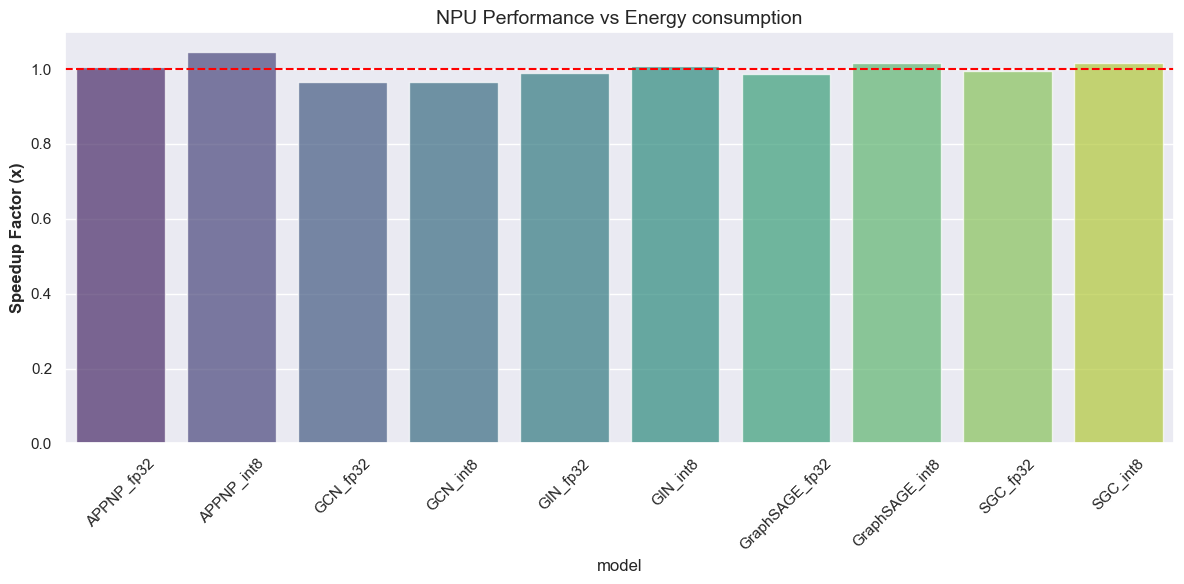

### 📍 ROOFLINE_MODEL.PNG

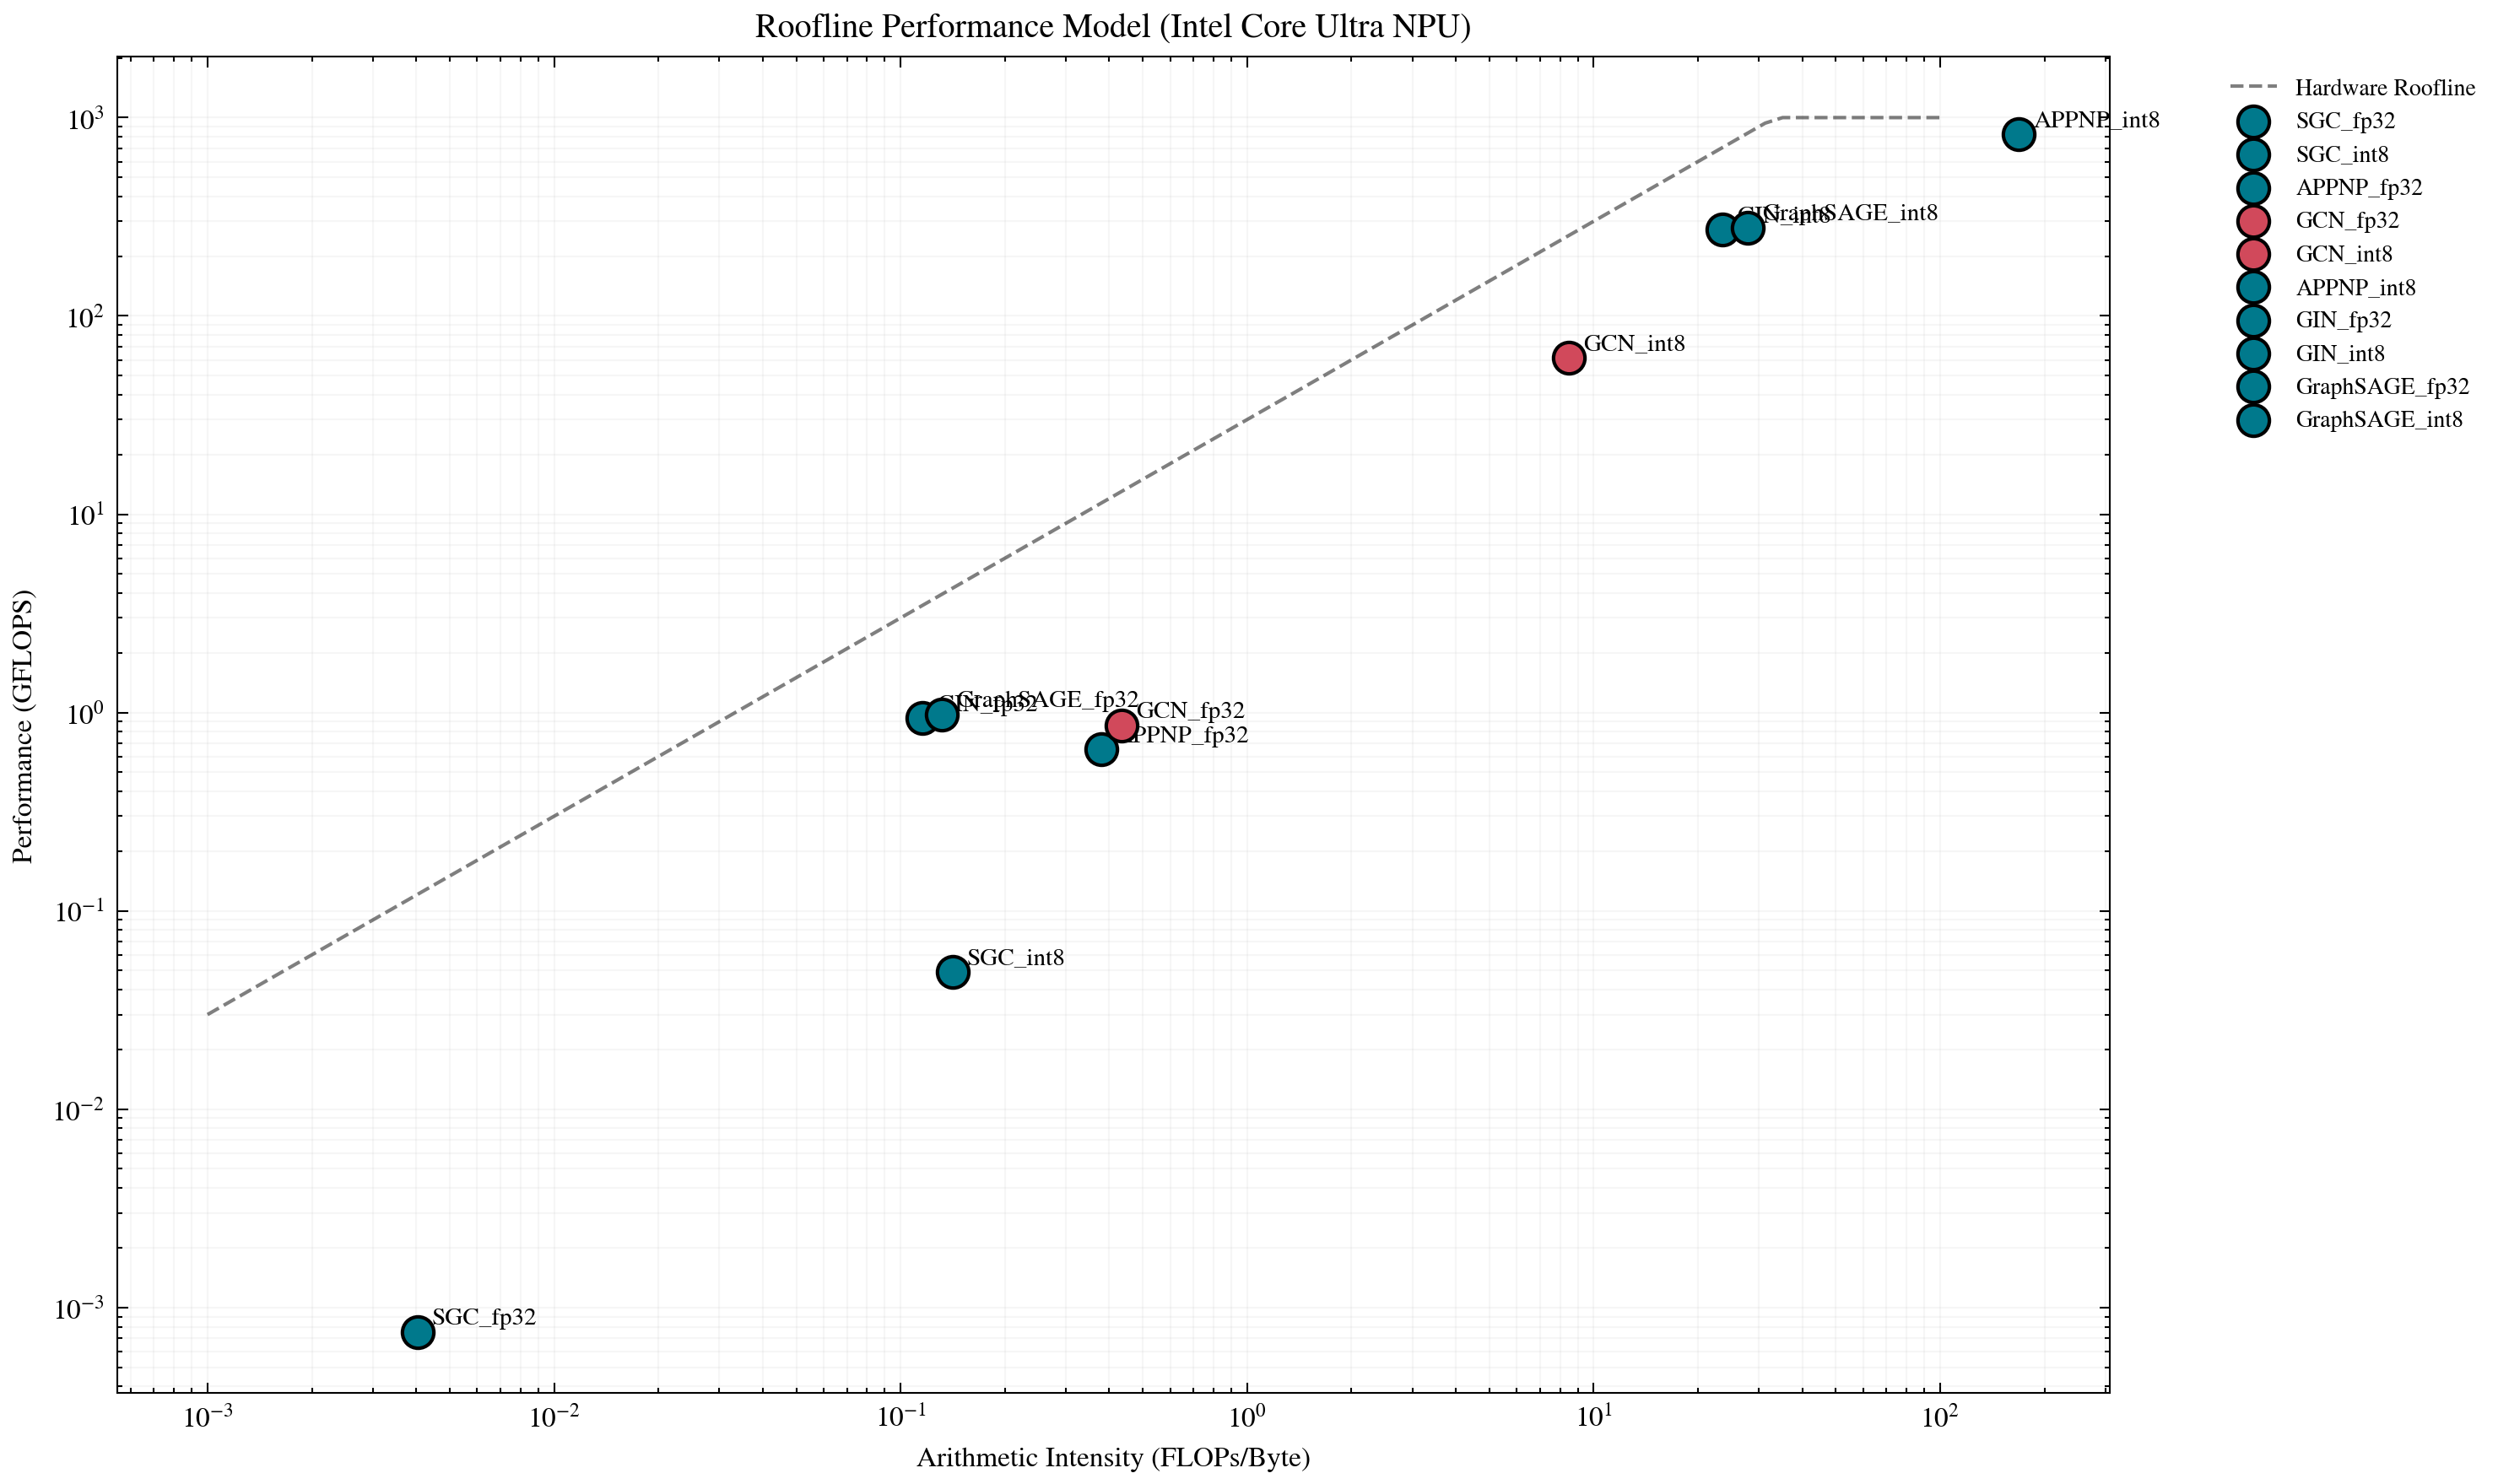

### 📍 LATENCY_STACKED_100PCT.PNG

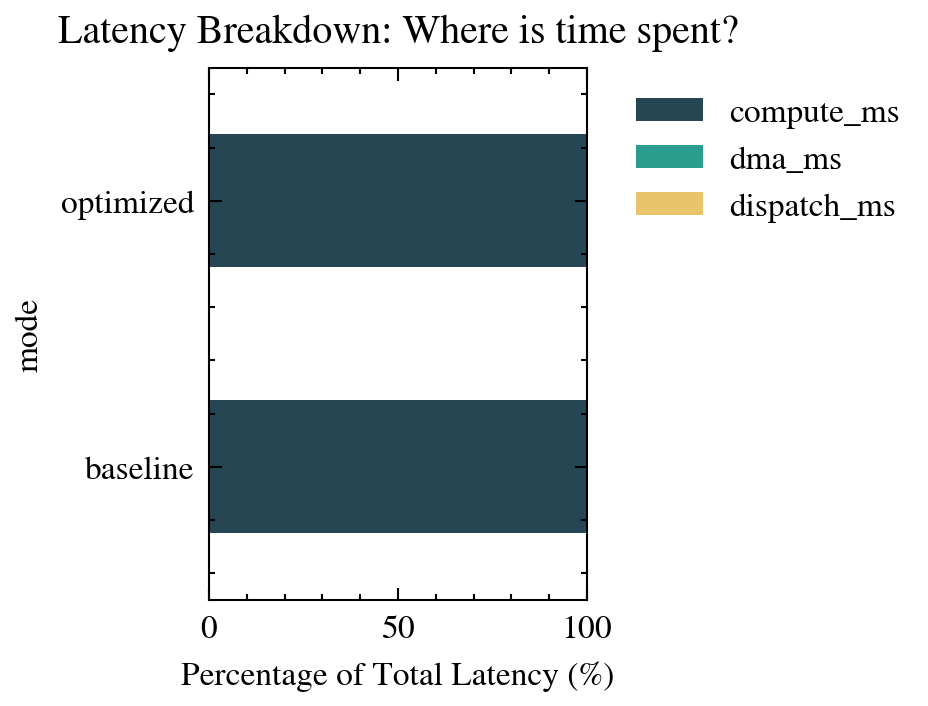

In [8]:
if Path(MATRIX_FILE).exists():
    df = pd.read_csv(MATRIX_FILE)
    
    fig, ax1 = plt.subplots(figsize=(12, 6))
    sns.barplot(data=df, x="model", y="speedup", hue="model", palette="viridis", legend=False, ax=ax1, alpha=0.7)
    ax1.set_ylabel("Speedup Factor (x)", fontweight='bold')
    ax1.axhline(1.0, color="red", ls="--")
    
    if "avg_npu_power_w" in df.columns:
        ax2 = ax1.twinx()
        sns.lineplot(data=df, x="model", y="avg_npu_power_w", color="#facc15", marker="o", ax=ax2, label="Avg Power (W)")
        ax2.set_ylabel("NPU Power Consumption (W)", color="#facc15", fontweight='bold')
    
    plt.title("NPU Performance vs Energy consumption", fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    # Artifacts
    for img in ["roofline_model.png", "latency_stacked_100pct.png"]:
        if (RESULTS_DIR / img).exists():
            display(Markdown(f"### 📍 {img.upper()}"))
            display(Image(filename=str(RESULTS_DIR / img), width=850))
else:
    print("❌ No data found.")
